# Machine Learning-Based Solar Energy Prediction

Solar energy is one of the pillars of the energy transition, offering a clean and 
increasingly accessible source of electricity. However, its output is highly dependent 
on environmental conditions — particularly weather — making it inherently variable and 
difficult to integrate efficiently into the grid.

This project addresses that challenge by predicting the hourly power output of a solar 
campus from publicly available weather data, using a machine learning model. The goal 
is to anticipate production levels in advance, enabling better planning and optimal 
use of solar energy.

## 1. Data Selection

Building a solar power prediction model requires a dataset that meets several key constraints:

- **Real measured production data** — simulated or synthetic data would not capture the variability and noise of actual solar installations
- **Meteorological features** — weather variables (temperature, humidity, irradiance) must be available at the same timestamps as production data
- **Multi-site coverage** — a single site would lead to an overfitted model; multiple sites with different capacities are necessary to learn a generalizable relationship
- **Sufficient time span** — at least one full year is required to capture seasonal patterns
- **Public availability** — the dataset must be openly accessible to ensure reproducibility

Several datasets were considered, including proprietary utility data and regional grid operator records. However, most either lack meteorological features, cover a single site, or are not publicly available.

The **[UNISOLAR dataset](https://www.kaggle.com/datasets/cdaclab/unisolar)**  (available on Kaggle) meets all of these constraints. It provides 15-minute resolution solar production data across multiple campuses in Australia, with site-level metadata including installed capacity (kWp) over a period spanning **2020 to 2022**.

## 2. Data Pipeline

### 2.1 Loading

The UNISOLAR dataset provides four files:

- `solar_production.csv` — 15-minute PV power output per site (kW), 2.7M rows across 5 campuses
- `site_details.csv` — site metadata: installed capacity (kWp), panel specs, GPS coordinates (42 sites)
- `weather.csv` — 15-minute meteorological data per campus from the Australian Bureau of Meteorology (BOM): apparent temperature, air temperature, dew point, relative humidity, wind speed and direction
- `summary.csv` — monthly aggregated statistics per site (average, min, max production)

In [254]:
import pandas as pd

# ── Load ──────────────────────────────────────────────────────
df_summary    = pd.read_csv('../data/summary.csv')
df_sites      = pd.read_csv('../data/site_details.csv')
df_production = pd.read_csv('../data/solar_production.csv', parse_dates=['Timestamp'])
df_weather    = pd.read_csv('../data/weather_unisolar.csv',          parse_dates=['Timestamp'])

#### 2.1.1 Summary (summary.csv)

In [255]:
print(f'Shape    : {df_summary.shape}')

display(df_summary.head())

Shape    : (1176, 7)


,SiteKey,Year,Month,DataStatus,AverageSolarGeneration,MaxSolarGeneration,MinSolarGeneration
0,1,2020,January,True,10.157125,21.778,0.101
1,2,2020,January,True,8.536875,18.553,0.100
2,3,2020,January,True,6.309834,13.322,0.103
3,4,2020,January,False,NaN,NaN,NaN
4,5,2020,January,False,NaN,NaN,NaN


This file provides monthly aggregated statistics — average, minimum and maximum 
production — per site and per year. While it offers a useful high-level overview 
of site performance, it brings no value to an hourly prediction model: aggregating 
production at the monthly level discards all the temporal and meteorological 
variability that the model is specifically designed to capture. This file will be 
ignored in the rest of the notebook.

#### 2.1.2 Sites (sites_details.csv)

In [256]:
print(f'Shape    : {df_sites.shape}')

display(df_sites.head())

print('Missing values :')
missing_sites = (
    df_sites.isna().mean() * 100
).round(2).rename('Missing (%)').to_frame().T

display(
    missing_sites
    .style
    .format('{:.2f}%')
)

Shape    : (42, 10)


,CampusKey,SiteKey,kWp,Number of panels,Panel,Inverter,Optimizers,Metric,lat,Lon
0,2,1,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
2,2,3,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
3,2,4,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
4,2,5,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679


Missing values :


,CampusKey,SiteKey,kWp,Number of panels,Panel,Inverter,Optimizers,Metric,lat,Lon
Missing (%),0.00%,0.00%,40.48%,40.48%,40.48%,40.48%,45.24%,40.48%,0.00%,0.00%


The site details file contains metadata for all **42 sites** across 5 campuses, 
including installed capacity (kWp), panel and inverter specifications, and GPS 
coordinates. 

**40.48% of kWp values are missing**, which is a critical issue: kWp (peak installed 
capacity) is the denominator used to compute the model target — 
`Efficiency = SolarGeneration / kWp`. Without it, the normalized target cannot 
be computed and the site cannot be included in training. A deeper analysis of the 
missing values by campus is therefore necessary to determine which sites are usable.

In [257]:
missing_kwp_by_campus = (
    df_sites.groupby('CampusKey')['kWp']
    .apply(lambda x: (x.isna().mean() * 100).round(2))
    .rename('Missing kWp (%)')
    .to_frame()
    .T
)

display(
    missing_kwp_by_campus
    .style
    .format('{:.2f}%')
    .background_gradient(axis=1, cmap='RdYlGn_r')
)

CampusKey,1,2,3,4,5
Missing kWp (%),7.41%,100.00%,100.00%,100.00%,100.00%


The per-campus breakdown is unambiguous: **campuses 2, 3, 4 and 5 have 100% missing 
kWp values**, making them entirely unusable for modelling. Only **Campus 1 (Bundoora)** 
has kWp data available, with a residual 7.41% missing rate that can be handled by 
dropping the concerned sites. The rest of this notebook focuses exclusively on Campus 1.

#### 2.1.3 Production (solar_production.csv)

In [258]:
df_production = df_production[df_production['CampusKey'] == 1]

print(f'Shape    : {df_production.shape}')
print(f'Sites    : {df_production["SiteKey"].nunique()}')
print(f'Period   : {df_production["Timestamp"].min()} → {df_production["Timestamp"].max()}')

missing_production = (
    df_production.isna().mean() * 100
).round(2).rename('Missing (%)').to_frame().T

display(
    missing_production
    .style
    .format('{:.2f}%')
    .background_gradient(axis=1, cmap='RdYlGn_r')
)

Shape    : (1720219, 4)
Sites    : 27
Period   : 2020-01-01 00:15:00 → 2022-04-23 23:45:00


,CampusKey,SiteKey,Timestamp,SolarGeneration
Missing (%),0.00%,0.00%,0.00%,55.87%


With **55.87% of `SolarGeneration` values missing**, a deeper analysis of the missing 
data distribution across hours is necessary before proceeding.

In [259]:
missing_by_hour = (
    df_production
    .assign(hour=df_production['Timestamp'].dt.hour)
    .groupby('hour')['SolarGeneration']
    .apply(lambda x: (x.isna().mean() * 100).round(2))
    .rename('Missing (%)')
    .to_frame()
    .T
)

display(
    missing_by_hour
    .style
    .format('{:.2f}%')
    .background_gradient(axis=1, cmap='RdYlGn_r')
)

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Missing (%),99.95%,99.93%,99.96%,99.96%,99.96%,99.96%,90.49%,48.85%,12.04%,6.24%,5.58%,6.45%,11.27%,14.64%,11.69%,6.27%,6.29%,25.92%,47.14%,58.84%,88.67%,99.95%,99.96%,99.96%


A per-hour analysis confirms that missing 
values are almost exclusively nocturnal — over 99% of records between 21:00 and 
06:00 are NaN, which simply reflects the absence of solar production at night. 
During daylight hours, the missing rate drops to under 15%, which is acceptable. 
The 56% global missing rate is therefore not a data quality concern but a 
natural consequence of the day/night cycle.

In [260]:
df_production = (
    df_production
    .dropna(subset=['SolarGeneration'])
    .sort_values('Timestamp')
    .reset_index(drop=True)
)

#### 2.1.4 Weather (weather_unisolar.csv)

In [261]:
df_weather = df_weather[df_weather['CampusKey'] == 1]

print(f'Shape    : {df_weather.shape}')
print(f'Period   : {df_weather["Timestamp"].min()} → {df_weather["Timestamp"].max()}')

missing_weather = (
    df_weather.isna().mean() * 100
).round(2).rename('Missing (%)').to_frame().T

display(
    missing_weather
    .style
    .format('{:.2f}%')
)

Shape    : (81017, 8)
Period   : 2020-01-01 00:00:00 → 2022-04-23 22:00:00


,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
Missing (%),0.00%,0.00%,18.26%,18.26%,18.26%,18.26%,36.65%,36.65%


In [262]:
missing_by_hour_weather = (
    df_weather
    .assign(hour=df_weather['Timestamp'].dt.hour)
    .groupby('hour')[['ApparentTemperature', 'AirTemperature', 'DewPointTemperature',
                       'RelativeHumidity', 'WindSpeed', 'WindDirection']]
    .apply(lambda x: (x.isna().mean() * 100).round(2))
    .T
)

display(
    missing_by_hour_weather
    .style
    .format('{:.2f}%')
    .background_gradient(axis=1, cmap='RdYlGn_r')
)

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
ApparentTemperature,18.25%,18.34%,18.42%,18.39%,18.28%,18.34%,18.25%,18.25%,18.28%,18.31%,18.25%,18.19%,18.13%,18.16%,17.92%,18.25%,18.25%,18.28%,18.31%,18.36%,18.31%,18.22%,18.26%,18.33%
AirTemperature,18.25%,18.34%,18.42%,18.39%,18.28%,18.34%,18.25%,18.25%,18.28%,18.31%,18.25%,18.19%,18.13%,18.16%,17.92%,18.25%,18.25%,18.28%,18.31%,18.36%,18.31%,18.22%,18.26%,18.33%
DewPointTemperature,18.25%,18.34%,18.42%,18.39%,18.28%,18.34%,18.25%,18.25%,18.28%,18.31%,18.25%,18.19%,18.13%,18.16%,17.92%,18.25%,18.25%,18.28%,18.31%,18.36%,18.31%,18.22%,18.26%,18.33%
RelativeHumidity,18.25%,18.34%,18.42%,18.39%,18.28%,18.34%,18.25%,18.25%,18.28%,18.31%,18.25%,18.19%,18.13%,18.16%,17.92%,18.25%,18.25%,18.28%,18.31%,18.36%,18.31%,18.22%,18.26%,18.33%
WindSpeed,36.49%,36.49%,36.64%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.67%,36.65%
WindDirection,36.49%,36.49%,36.64%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.67%,36.65%


The missing value analysis confirms that the BOM weather data is not reliable enough 
to serve as the primary meteorological source. On Campus 1, missing rates range from 
**~18%** on temperature and humidity variables to **~36%** on wind variables — making 
this dataset unsuitable for model training.

A more reliable alternative would be to replace this source with a complete historical 
weather, capable of providing gap-free meteorological data for any location and 
time period. This approach will be explored in the next section.

### 2.2 Data Preparation

#### 2.2.1 Weather Source Replacement

As discussed in section 2.1.4, the BOM weather data is unsuitable for model training. 
A replacement source is therefore needed — one that provides complete hourly data 
for any location and time period.

The **[Open-Meteo Historical API](https://open-meteo.com/en/docs/historical-weather-api)** 
meets this requirement. Hourly meteorological records are fetched for the exact GPS 
coordinates of the Bundoora campus, covering the same time period as the UNISOLAR 
production data. The resulting dataset is complete with no missing values.

This approach also exposes **`shortwave_radiation`** — a direct measurement of solar 
irradiance (W/m²) unavailable in the BOM dataset — opening the possibility of using 
irradiance as a feature, which will be explored in the feature engineering section.

A key advantage of this choice is that the Open-Meteo Historical API shares identical 
variables with the Open-Meteo Forecast API used at inference time, ensuring full 
alignment between training model and future production prediction.

`AirTemperature` is excluded from the retrieved variables as it is highly correlated 
with `ApparentTemperature`, which already encodes temperature combined with wind and 
humidity effects — making `AirTemperature` redundant.

The Open-Meteo Historical API was called once to fetch hourly meteorological data 
for the full production period and saved to `weather_open_meteo.csv`. 
The file is loaded below to replace the BOM weather dataset.

We can retrieve the historical weather for our model. Knowing that `AirTemperature` will be excluded from the feature set as it is highly correlated with `ApparentTemperature`, which already encodes temperature combined with wind and 
humidity effects — making `AirTemperature` redundant.

The Open-Meteo Historical API was called once to fetch hourly meteorological data 
for the full production period and saved to `weather_open_meteo.csv`. 
The file is loaded below to replace the BOM weather dataset.

In [263]:
df_weather = pd.read_csv('../data/weather_open_meteo.csv', parse_dates=['timestamp'])

print(f'Shape : {df_weather.shape}')
print(f'NaN   : {df_weather.isna().sum().sum()}')
df_weather.head()

Shape : (20088, 5)
NaN   : 0


,timestamp,apparent_temperature,relative_humidity,dew_point_temperature,shortwave_radiation
0,2020-01-08 00:00:00,15.8,95,15.1,0.0
1,2020-01-08 01:00:00,15.8,95,14.9,0.0
2,2020-01-08 02:00:00,15.7,94,14.9,0.0
3,2020-01-08 03:00:00,15.7,93,14.8,0.0
4,2020-01-08 04:00:00,15.9,91,14.5,0.0


#### 2.2.2 Hourly Aggregation

`SolarGeneration` is an **instantaneous power measurement in kW** recorded every 
15 minutes. To align with the hourly resolution of the Open-Meteo weather data, 
production records are aggregated to hourly frequency.

The aggregation uses the **mean** of the 4 measurements within each hour, yielding 
the average power output in kW for that hour. A sum would be inappropriate here 
as it would change the unit from kW (power) to kWh (energy), inconsistent with 
the hourly irradiance values provided by the weather API.

In [264]:
df_production['timestamp'] = df_production['Timestamp'].dt.floor('H')

df_production = (
    df_production
    .groupby(['SiteKey', 'timestamp'])
    .agg(solar_generation=('SolarGeneration', 'mean'))
    .reset_index()
)

print(f'Shape  : {len(df_production):,} lines')
df_production.head()

Shape  : 211,014 lines


,SiteKey,timestamp,solar_generation
0,14,2020-06-14 08:00:00,0.575512
1,14,2020-06-14 09:00:00,2.452072
2,14,2020-06-14 10:00:00,5.123543
3,14,2020-06-14 11:00:00,6.688988
4,14,2020-06-14 12:00:00,6.022491


### 2.2.3 Merge

Production and weather data are merged on `timestamp`. Only hours present 
in both datasets are kept (`inner` join).

In [265]:
df = (
    df_production
    .merge(df_weather, on='timestamp', how='inner')
    .merge(df_sites[['SiteKey', 'kWp']].dropna(), on='SiteKey', how='inner')
)

print(f'Shape  : {len(df):,} records')
print(f'Sites  : {df["SiteKey"].nunique()}')

display(df.head())

display(
    (df.isna().mean() * 100)
    .round(2)
    .rename('Missing (%)')
    .to_frame()
    .T
    .style
    .format('{:.2f}%')
    .background_gradient(axis=1, cmap='RdYlGn_r')
)

Shape  : 197,291 records
Sites  : 25


,SiteKey,timestamp,solar_generation,apparent_temperature,relative_humidity,dew_point_temperature,shortwave_radiation,kWp
0,14,2020-06-14 08:00:00,0.575512,6.2,84,6.4,2.0,66.0
1,14,2020-06-14 09:00:00,2.452072,6.5,83,6.7,96.0,66.0
2,14,2020-06-14 10:00:00,5.123543,8.4,76,7.3,237.0,66.0
3,14,2020-06-14 11:00:00,6.688988,8.7,68,6.7,371.0,66.0
4,14,2020-06-14 12:00:00,6.022491,9.2,61,5.8,439.0,66.0


,SiteKey,timestamp,solar_generation,apparent_temperature,relative_humidity,dew_point_temperature,shortwave_radiation,kWp
Missing (%),0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


The merged dataset contains **197,291 hourly records** across **25 sites**, covering 
the period 2020-06-14 to 2022-04-23. All columns are present with no missing values. 
The dataset is now ready for feature engineering and model training.

### 2.3 Data Cleaning
#### 2.3.1 Target Computation

The model target is defined as `efficiency = solar_generation / kWp` — the ratio 
of actual power output to installed peak capacity. This normalization allows a single 
model to generalize across all 25 sites regardless of their installed capacity.

In [266]:
df['efficiency'] = df['solar_generation'] / df['kWp']

print(f'efficiency min  : {df["efficiency"].min():.4f}')
print(f'efficiency max  : {df["efficiency"].max():.4f}')
print(f'efficiency mean : {df["efficiency"].mean():.4f}')

efficiency min  : 0.0002
efficiency max  : 1.2302
efficiency mean : 0.0850


A preliminary inspection shows a mean efficiency of **0.085** — consistent with the 
inclusion of nocturnal hours where production is near zero. However, the maximum 
value of **1.23** reveals physically impossible records that must be cleaned before 
training.

#### 2.3.2 Physical Constraints

Solar panel efficiency is bounded by the laws of physics: a panel cannot produce 
negative power, and its output cannot exceed its installed peak capacity. Any record 
violating these constraints is therefore not a legitimate measurement — it is the 
result of a sensor fault, a data entry error, or a measurement artifact.

Two filters are applied:
- `efficiency < 0` — negative production is physically impossible
- `efficiency > 1` — production exceeding installed peak capacity is physically impossible

These records are dropped unconditionally, regardless of their proportion in the dataset.

In [267]:
mask = (df['efficiency'] < 0) | (df['efficiency'] > 1)

n_before = len(df)
df       = df[~mask].reset_index(drop=True)
n_after  = len(df)

print(f'Removed : {n_before - n_after:,} ({(n_before - n_after) / n_before * 100:.2f}%)')
print(f'Kept    : {n_after:,}')
print(f'\nefficiency min  : {df["efficiency"].min():.4f}')
print(f'efficiency max  : {df["efficiency"].max():.4f}')
print(f'efficiency mean : {df["efficiency"].mean():.4f}')

Removed : 656 (0.33%)
Kept    : 196,635

efficiency min  : 0.0002
efficiency max  : 1.0000
efficiency mean : 0.0816


#### 2.3.3 Results

**656 records removed (0.33%)**, leaving **196,635 clean records**. The efficiency 
range is now strictly bounded between **0.0002 and 1.0000**, confirming that all 
physically impossible values have been eliminated. The mean efficiency of **0.082** 
is consistent with the expected distribution — dominated by near-zero nocturnal hours 
and moderate daytime production across 25 sites of varying capacity.

### 2.4 Feature Engineering

#### 2.4.1 Cyclic Encoding

Hour and month are periodic variables — hour 23 is closer to hour 0 than to hour 12. 
A naive integer encoding would not capture this continuity. Sin/cos encoding maps 
each value onto a unit circle, preserving the cyclic nature of time.

In [298]:
import numpy as np

df['hour']  = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

df['h_sin'] = np.sin(2 * np.pi * df['hour']  / 24)
df['h_cos'] = np.cos(2 * np.pi * df['hour']  / 24)
df['m_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['m_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.drop(columns=['hour', 'month'], inplace=True)

#### 2.4.2 Feature Set

The final feature set used for training:

| Feature | Description |
|---|---|
| `apparent_temperature` | Temperature felt (°C) — encodes temperature + wind + humidity |
| `relative_humidity` | Relative humidity (%) |
| `dew_point_temperature` | Dew point temperature (°C) |
| `shortwave_radiation` | Solar irradiance (W/m²) — primary predictor |
| `h_sin`, `h_cos` | Cyclic encoding of hour |
| `m_sin`, `m_cos` | Cyclic encoding of month |
| `kWp` | Installed peak capacity — enables multi-site generalization |

**Target** : `efficiency = solar_generation / kWp`

In [299]:
display(df.head())

,SiteKey,timestamp,solar_generation,apparent_temperature,relative_humidity,dew_point_temperature,shortwave_radiation,kwp,efficiency,h_sin,h_cos,m_sin,m_cos
0,14,2020-06-14 08:00:00,0.575512,6.2,84,6.4,2.0,66.0,0.008720,8.660254e-01,-0.500000,1.224647e-16,-1.0
1,14,2020-06-14 09:00:00,2.452072,6.5,83,6.7,96.0,66.0,0.037153,7.071068e-01,-0.707107,1.224647e-16,-1.0
2,14,2020-06-14 10:00:00,5.123543,8.4,76,7.3,237.0,66.0,0.077629,5.000000e-01,-0.866025,1.224647e-16,-1.0
3,14,2020-06-14 11:00:00,6.688988,8.7,68,6.7,371.0,66.0,0.101348,2.588190e-01,-0.965926,1.224647e-16,-1.0
4,14,2020-06-14 12:00:00,6.022491,9.2,61,5.8,439.0,66.0,0.091250,1.224647e-16,-1.000000,1.224647e-16,-1.0


## 3. Modelling

In [270]:
df = df.rename(columns={'kWp': 'kwp'})

FEATURES = [
    'apparent_temperature',
    'relative_humidity',
    'dew_point_temperature',
    'shortwave_radiation',
    'h_sin', 'h_cos',
    'm_sin', 'm_cos',
    'kwp',
]
TARGET = 'efficiency'

print('Features :', FEATURES)
print('Target   :', TARGET)
print(f'Shape    : {df[FEATURES + [TARGET]].shape}')

Features : ['apparent_temperature', 'relative_humidity', 'dew_point_temperature', 'shortwave_radiation', 'h_sin', 'h_cos', 'm_sin', 'm_cos', 'kwp']
Target   : efficiency
Shape    : (196635, 10)


### 3.1 Train / Test Split

The dataset is split chronologically — the first 80% of records are used for 
training, the last 20% for testing. A random split would leak future information 
into the training set, which is not representative of real-world forecasting conditions.

In [271]:
df_sorted  = df.sort_values('timestamp').reset_index(drop=True)
split_idx  = int(len(df_sorted) * 0.8)
df_train   = df_sorted.iloc[:split_idx]
df_test    = df_sorted.iloc[split_idx:]

X_train = df_train[FEATURES].values
y_train = df_train[TARGET].values
X_test  = df_test[FEATURES].values
y_test  = df_test[TARGET].values

print(f'Train : {len(df_train):,}')
print(f'Test  : {len(df_test):,}')

Train : 157,308
Test  : 39,327


### 3.2 Model Comparison

Three models are evaluated on this dataset. The choice is motivated by the nature 
of the data — **tabular, structured, with mixed feature types** (meteorological 
variables, cyclic encodings, and a capacity feature).

- **Random Forest** — well suited for tabular data with non-linear relationships 
  between features. The relationship between solar irradiance, temperature and 
  production is not linear, and RF captures these interactions naturally through 
  its tree structure without requiring feature scaling.

- **Gradient Boosting** — shares the same strengths as Random Forest but builds 
  trees sequentially, focusing each new tree on the residual errors of the previous 
  ones. This iterative correction mechanism makes it particularly effective on 
  datasets where the signal is strong but the relationship between features and 
  target is complex — which is the case here.

- **Neural Network** — included to assess whether a deep learning approach can 
  capture additional non-linear patterns that tree-based models might miss. 
  Features are normalized prior to training, as neural networks are sensitive 
  to input scale.

#### 3.2.1 Random Forest

In [272]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

SEED = 42

results = {}

rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = np.clip(rf.predict(X_test), 0, None)
results['RandomForest'] = {
    'r2':    r2_score(y_test, y_pred),
    'mae':   mean_absolute_error(y_test, y_pred),
    'model': rf,
    'preds': y_pred,
}
print(f"R²={results['RandomForest']['r2']:.4f}  MAE={results['RandomForest']['mae']:.4f}")

R²=0.8619  MAE=0.0213


The Random Forest achieves a strong R² of **0.86** with no hyperparameter tuning. 
This result directly validates the core hypothesis of this project: meteorological 
data alone is sufficient to predict solar power output with high accuracy. The 
relevance of a machine learning approach for this problem is confirmed.

#### 3.2.2 Gradient Boosting

Unlike Random Forest which builds trees independently in parallel, Gradient Boosting 
builds them sequentially — each tree is trained to correct the residual errors of 
the previous one. This iterative refinement generally yields better performance 
than Random Forest on structured tabular data, at the cost of a longer training time.

A grid search is performed over key hyperparameters to find the optimal configuration:
- `n_estimators` — number of trees in the sequence
- `max_depth` — maximum depth of each tree, controls model complexity
- `learning_rate` — shrinkage applied to each tree's contribution, lower values 
  require more trees but generalize better
- `subsample` — fraction of samples used per tree, introduces stochasticity 
  to reduce overfitting

In [273]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators':  [300, 500],
    'max_depth':     [4, 5, 6],
    'learning_rate': [0.05, 0.01],
    'subsample':     [0.8, 1.0],
}
gs = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1,
)
gs.fit(X_train, y_train)
print(f'Best params : {gs.best_params_}')

y_pred = np.clip(gs.best_estimator_.predict(X_test), 0, None)
results['GradientBoosting'] = {
    'r2':    r2_score(y_test, y_pred),
    'mae':   mean_absolute_error(y_test, y_pred),
    'model': gs.best_estimator_,
    'preds': y_pred,
}
print(f"R²={results['GradientBoosting']['r2']:.4f}  MAE={results['GradientBoosting']['mae']:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
R²=0.8671  MAE=0.0209


Gradient Boosting marginally improves on Random Forest (R² 0.862 → 0.867), 
confirming that sequential tree building — where each tree corrects the errors 
of the previous one — captures additional signal that parallel ensembles miss.

The grid search converges on a moderate learning rate of 0.05 paired with 300 trees, 
a classic combination that balances convergence speed and generalization. 
The `subsample=0.8` parameter trains each tree on 80% of the data, 
reducing the risk of overfitting.

#### 3.2.3 Neural Network

A dense neural network is trained as a third approach. `BatchNormalization` is added 
after each hidden layer to stabilize training — particularly important here as features 
have very different scales (`shortwave_radiation` in W/m² vs `relative_humidity` in %). 
`AdamW` is used as optimizer, which integrates L2 regularization directly and generally 
outperforms standard `Adam` on tabular data. Early stopping with `restore_best_weights` 
ensures the best validation state is always restored.

In [274]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(SEED)

# Normalization — required for neural networks
scaler     = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

nn = keras.Sequential([
    layers.Input(shape=(len(FEATURES),)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear'),
])
nn.compile(
    optimizer=keras.optimizers.AdamW(1e-3, weight_decay=1e-4),
    loss='mse',
    metrics=['mae'],
)
nn.fit(
    X_train_sc, y_train,
    validation_split=0.1,
    epochs=150,
    batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=7, factor=0.5, verbose=0),
    ],
    verbose=1,
)

y_pred = np.clip(nn.predict(X_test_sc, verbose=0).flatten(), 0, None)
results['NeuralNetwork'] = {
    'r2':    r2_score(y_test, y_pred),
    'mae':   mean_absolute_error(y_test, y_pred),
    'model': nn,
    'preds': y_pred,
}
print(f"R²={results['NeuralNetwork']['r2']:.4f}  MAE={results['NeuralNetwork']['mae']:.4f}")

Epoch 1/150
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1119 - mae: 0.2218 - val_loss: 0.0087 - val_mae: 0.0489 - learning_rate: 0.0010
Epoch 2/150
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0100 - mae: 0.0618 - val_loss: 0.0077 - val_mae: 0.0427 - learning_rate: 0.0010
Epoch 3/150
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0077 - mae: 0.0482 - val_loss: 0.0074 - val_mae: 0.0385 - learning_rate: 0.0010
Epoch 4/150
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0071 - mae: 0.0430 - val_loss: 0.0073 - val_mae: 0.0388 - learning_rate: 0.0010
Epoch 5/150
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - mae: 0.0410 - val_loss: 0.0071 - val_mae: 0.0395 - learning_rate: 0.0010
Epoch 6/150
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0065 - mae: 0.0399 - val_loss: 0.0070 - val_mae: 0.0371 - learning_rate: 0.0010
Epoch 7/150
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0064 - mae: 0.0392 - val_loss: 0.0070 - val_mae: 0.0395 - learning_rate: 0.0010

Despite a deeper architecture and careful regularization, the neural network 
underperforms both tree-based models. 

#### 3.2.4 Results

In [276]:
df_results = (
    pd.DataFrame([{'Model': k, 'R²': v['r2'], 'MAE': v['mae']} for k, v in results.items()])
    .sort_values('R²', ascending=False)
    .reset_index(drop=True)
)
display(df_results)

,Model,R²,MAE
0,GradientBoosting,0.867055,0.020918
1,RandomForest,0.861915,0.021291
2,NeuralNetwork,0.859019,0.023109


Gradient Boosting achieves the best R² and lowest MAE across all three models 
and is selected as the final model.

### 3.3 Final Model

The final model is a Gradient Boosting regressor trained with the optimal 
hyperparameters identified during the grid search. The model is retrained 
on the full training set to ensure reproducibility with a fixed random seed.

In [278]:
final_model = GradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    n_estimators=300,
    subsample=0.8,
    random_state=SEED,
)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
r2_final     = r2_score(y_test, y_pred_final)
mae_final    = mean_absolute_error(y_test, y_pred_final)

print(f'R²  : {r2_final:.4f}')
print(f'MAE : {mae_final:.4f}')

R²  : 0.8670
MAE : 0.0209


#### 3.3.1 Feature Importance

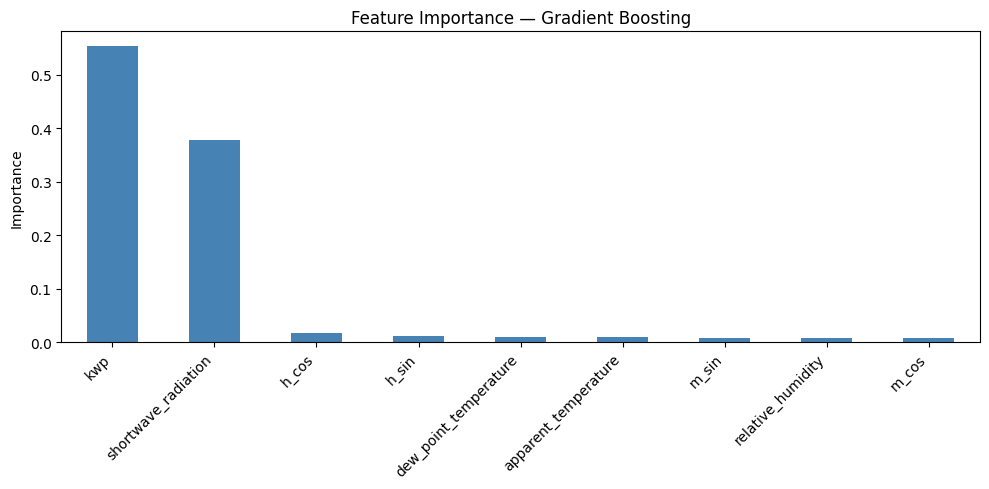

In [281]:
import matplotlib.pyplot as plt

feat_imp = (
    pd.Series(final_model.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Feature Importance — Gradient Boosting')
ax.set_ylabel('Importance')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The feature importance confirms the physical intuition behind the model. 
`kwp` dominates at **55%** — which is expected since efficiency is normalized 
by kWp, making the installed capacity the primary scaling factor. 
`shortwave_radiation` follows at **38%**, confirming that solar irradiance 
is the main meteorological driver of production. All other features 
(cyclic encodings, temperature, humidity) contribute less than **3%** each, 
playing a secondary role in capturing residual variability.

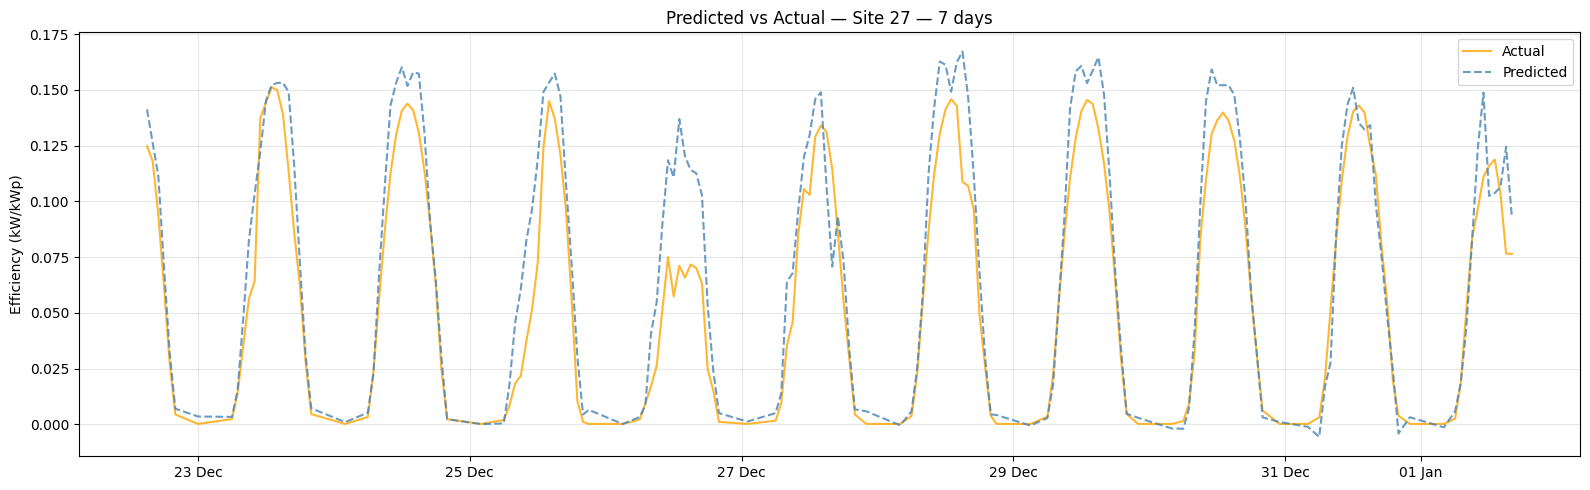

In [285]:
import matplotlib.dates as mdates

test_pos = df_test.reset_index(drop=True)
top_site = test_pos['SiteKey'].value_counts().idxmax()
sample   = test_pos[test_pos['SiteKey'] == top_site].iloc[:168]
idx      = sample.index.tolist()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample['timestamp'].values, y_test[idx],
        color='orange', alpha=0.8, label='Actual')
ax.plot(sample['timestamp'].values, y_pred_final[idx],
        color='steelblue', alpha=0.8, linestyle='--', label='Predicted')
ax.set_ylabel('Efficiency (kW/kWp)')
ax.set_title(f'Predicted vs Actual — Site {top_site} — 7 days')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The model captures the day/night cycle accurately — production drops to zero every 
night and rises during daylight hours. On clear days the predicted curve closely 
follows the actual one. The main discrepancies appear on days with variable 
irradiance (27 Dec) where the model struggles to capture rapid fluctuations — 
these short-term variations occur at the minute scale and cannot be captured 
from hourly weather data alone. This is an expected limitation that does not 
affect the overall reliability of the model for daily production planning.

#### 3.3.3 Save Artefacts

In [297]:
import joblib
import os

os.makedirs('../model', exist_ok=True)

df_sites_final = pd.read_csv('../data/sites_final.csv')

joblib.dump(final_model, '../model/model_solar_prediction.pkl')
joblib.dump({
    'features':       FEATURES,
    'target':         TARGET,
    'best_model':     'GradientBoosting',
    'r2_final':       float(r2_final),
    'mae_final':      float(mae_final),
    'kwp_moyen':      float(df['kwp'].mean()),
    'date_train_end': str(df_train['timestamp'].max().date()),
    'hyperparams': {
        'learning_rate': 0.05,
        'max_depth':     6,
        'n_estimators':  300,
        'subsample':     0.8,
    },
    'sites': df_sites_final[['id', 'site_key', 'kwp']].to_dict('records'),
}, '../model/features_info.pkl')

print('✓ ../model/model_solar_prediction.pkl')
print('✓ ../model/features_info.pkl')

print(f'\nR²={r2_final:.4f}  MAE={mae_final:.4f}')

✓ ../model/model_solar_prediction.pkl
✓ ../model/features_info.pkl

R²=0.8670  MAE=0.0209


## 4. Conclusion

This project demonstrates that solar power output can be predicted with high accuracy 
(**R² = 0.867**) from publicly available weather data alone, using a Gradient Boosting 
model trained on the UNISOLAR dataset.

**Key findings**:
- `shortwave_radiation` is the primary meteorological driver of solar production (38% feature importance)
- `kwp` is the dominant feature (55%) — normalizing the target by installed capacity enables a single model to generalize across all 25 sites
- Tree-based models outperform neural networks on this structured tabular dataset
- The model accurately captures the day/night cycle and seasonal patterns, with residual errors concentrated on days with rapidly variable irradiance

**Limitations**
- The model is trained exclusively on the Bundoora campus and is not intended to generalize to other locations
- Hourly weather data cannot capture sub-hourly irradiance fluctuations due to cloud cover
- The training period (2020–2022) may not fully represent long-term climate variability